## Importação das Bibliotecas

In [63]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

### Carregando dados

In [64]:
df = pd.read_csv('../../data/base_funcionarios_v3.csv')
df.shape

(46, 5)

In [65]:
df.head()

,Unnamed: 0,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira
0,0,5517.4,3,3,9.777079
1,1,6399.9,4,6,3.765998
2,2,6206.7,6,3,7.926264
3,3,6060.6,4,5,2.233497
4,4,6122.7,2,9,26.821842


## Limpeza e Preparação

### Visão Inicial dos dados

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          46 non-null     int64  
 1   Salario             46 non-null     float64
 2   Anos_Educ_Superior  46 non-null     int64  
 3   Tempo_Empresa       46 non-null     int64  
 4   Tempo_de_Carreira   46 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 1.9 KB


### Removendo Colunas

In [67]:
df = df.drop(columns="Unnamed: 0")
df.head()

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira
0,5517.4,3,3,9.777079
1,6399.9,4,6,3.765998
2,6206.7,6,3,7.926264
3,6060.6,4,5,2.233497
4,6122.7,2,9,26.821842


### Procurando por Valores Faltantes e Duplicatas

In [68]:
df.isna().sum()

Salario               0
Anos_Educ_Superior    0
Tempo_Empresa         0
Tempo_de_Carreira     0
dtype: int64

In [69]:
df.duplicated().sum()

np.int64(0)

### Verificando Outliers e Anomalias

In [70]:
df.describe()

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira
count,46.000000,46.000000,46.000000,46.000000
mean,6969.797826,5.065217,10.326087,21.194106
std,1924.868873,2.839422,7.601328,15.869038
min,4139.500000,0.000000,0.000000,-3.235467
25%,5818.350000,4.000000,5.250000,9.621697
50%,6394.750000,5.000000,8.500000,17.689876
75%,7972.400000,6.000000,17.250000,29.773380
max,12118.100000,12.000000,27.000000,67.858714


#### Anomalia: Tempo_de_Carreira < 0


In [71]:
df.loc[df['Tempo_de_Carreira'] < 0]

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira
19,5072.4,4,0,-3.235467


Correção: transformar valores negativos em zero.

In [72]:
df.loc[df['Tempo_de_Carreira'] < 0, 'Tempo_de_Carreira'] = 0

## Análise Exploratória de Dados

### Visão Geral do relacionamento dos dados entre si

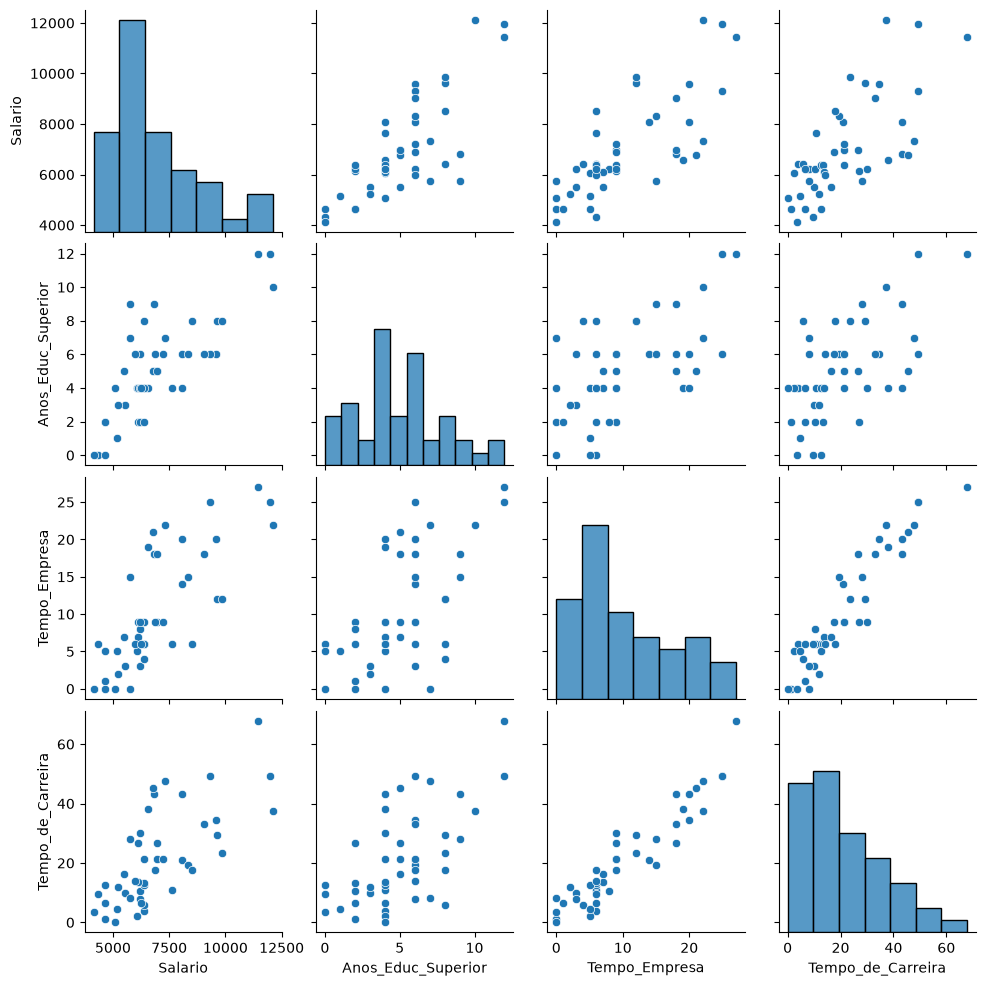

In [73]:
sns.pairplot(df)

### Verificando o Coeficiente de Correlação das variáveis (método Pearson)

<Axes: >

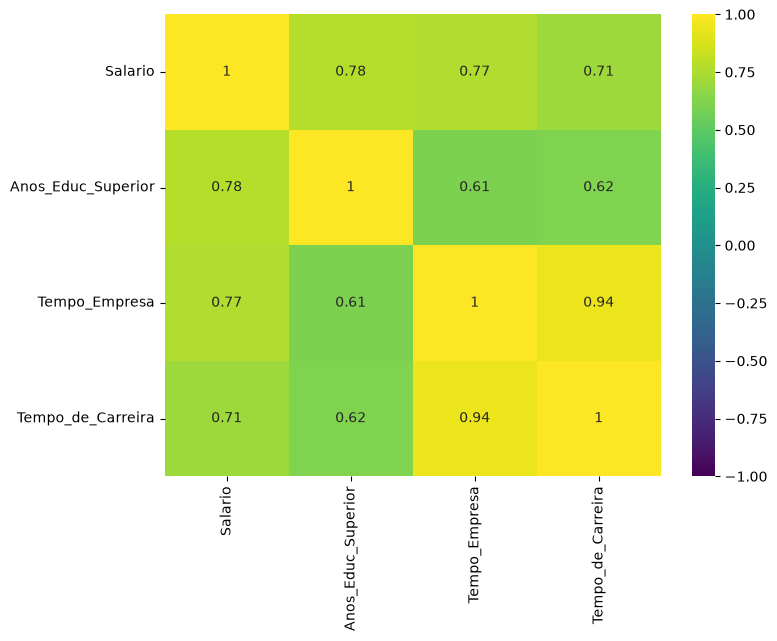

In [74]:
fig = plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, cmap='viridis')

é possível observar a existência de multicolinearidade entre as *features* e o *target* (Salário)

## Treinando um modelo de Regressão Linear Multipla

In [75]:
# definindo o target
y = df['Salario']

# definindo as features + intercepto
df['Intercepto'] = 1
x = df.drop(columns='Salario')

In [76]:
# Ajustando o modelo
modelo = sm.OLS(y, x)
resultado = modelo.fit()

In [77]:
# Analisando resultados
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     41.73
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           1.15e-12
Time:                        15:07:58   Log-Likelihood:                -380.87
No. Observations:                  46   AIC:                             769.7
Df Residuals:                      42   BIC:                             777.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Anos_Educ_Superior   348.8244     66

Apesar do modelo apresentar um desempenho bom, com um R² ajustado igual a 0.731, a cariável "Tempo_de_Carreira" possui um p-valor alto. Vale a pena testar o desempenho de um modelo treinado sem ela.

In [78]:
# Ajustando as features
x = df.drop(columns=['Salario', 'Tempo_de_Carreira'])

# Treinando um novo modelo
modelo_ajustado = sm.OLS(y, x)
resultado_ajustado = modelo_ajustado.fit()

# Analisando os  resultados
print(resultado_ajustado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     61.17
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           2.66e-13
Time:                        15:07:58   Log-Likelihood:                -381.67
No. Observations:                  46   AIC:                             769.3
Df Residuals:                      43   BIC:                             774.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Anos_Educ_Superior   335.3868     66

O modelo não apresenta uma queda significativa de desempenho ao remover uma das features (R² ajustado: 0.731 -> 0.728).

### Equação do modelo:
Salário = $\beta_0$ + $\beta_1$ x Anos Educação Superior + $\beta_2$ x Tempo Empresa

<br>Onde:</br>
- $\beta_0$ = 4056.05
- $\beta_1$ = 335.38
- $\beta_2$ = 117.65

### Interpretação do Modelo
- $\beta_0$: Salário médio de um colaborador sem educação superior e recém chegado na empresa é de ``R$ 4056,05``
- $\beta_1$: Para cada **ano de educação superior** que o colaborador tem, mantendo o tempo de empresa constante, seu salário aumenta em média ``R$ 335,38``
- $\beta_2$: Para cada **ano que o colaborador está na empresa**, mantendo o tempo de educação superior constante, seu salário aumenta em média ``R$ 117,65``

## Diagnóstico do Modelo

### Análise de Resíduos

In [79]:
def grafico_residuos(resultado):
    resid_graf = sns.scatterplot(x=list(range(0,len(resultado.resid_pearson))),
                                 y=resultado.resid_pearson.tolist())
    
    # Localizando valor mínimo dos resíduos
    r_aux = resultado.resid_pearson.tolist()
    r_aux.append(-3)
    ymin = min(r_aux) * 1.1
    
    # Localizando valor máximo dos resíduos
    r_aux = resultado.resid_pearson.tolist()
    r_aux.append(+3)
    ymax = max(r_aux) * 1.1
    
    resid_graf.set(ylim=(ymin, ymax))
    
    ax1 = resid_graf.axes
    ax1.axhline( 0, color='black', ls='--')
    ax1.axhline(-2, color='black', ls='--')
    ax1.axhline(+2, color='black', ls='--')
    plt.show()

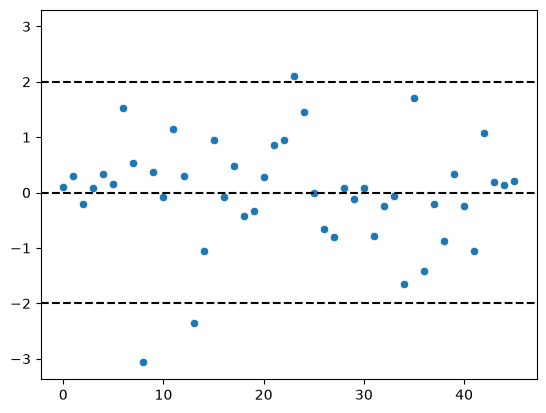

In [80]:
grafico_residuos(resultado_ajustado)

### Normalidade dos resíduos

C:\Users\Sam\AppData\Local\Temp\ipykernel_12756\731889017.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(resultado_ajustado.resid_pearson)


<Axes: ylabel='Density'>

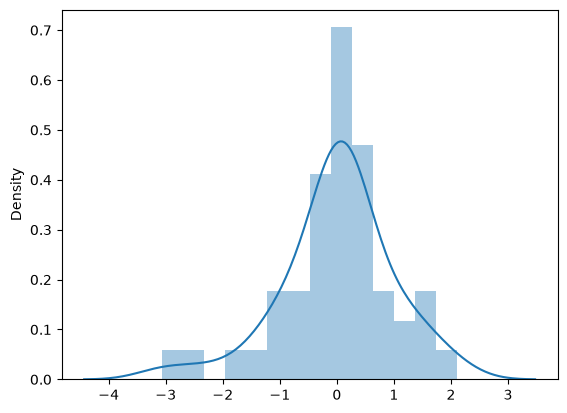

In [81]:
sns.distplot(resultado_ajustado.resid_pearson)

In [82]:
# Realização de Teste de Hipóteses para avaliar Normalidade
from scipy.stats import shapiro
normalidade = shapiro(resultado_ajustado.resid_pearson)
print('Estatística=%.3f, p-valor=%.3f\n' % (normalidade.statistic, normalidade.pvalue))

Estatística=0.952, p-valor=0.057



### Homocedasticidade dos resíduos

In [83]:
from statsmodels.stats.diagnostic import het_white
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

white_test = het_white(resultado_ajustado.resid_pearson,
                       resultado_ajustado.model.exog)

print(dict(zip(labels, white_test)))

{'LM Statistic': np.float64(14.662862054240158), 'LM-Test p-value': np.float64(0.011904321801030284), 'F-Statistic': np.float64(3.7432549404146607), 'F-Test p-value': np.float64(0.007127185674387404)}
